# Detecting outliers using z-score

Using the normal distribution curve, we can predict that anything over (mean +- 3sigma) is an outlier.

We can then use trimming or capping to deal with the outliers themselves

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('placement.csv')

In [5]:
df.sample(5)

,cgpa,placement_exam_marks,placed
798,5.86,56.0,0
990,6.17,33.0,1
977,7.18,49.0,0
598,7.59,27.0,1
655,7.36,34.0,0


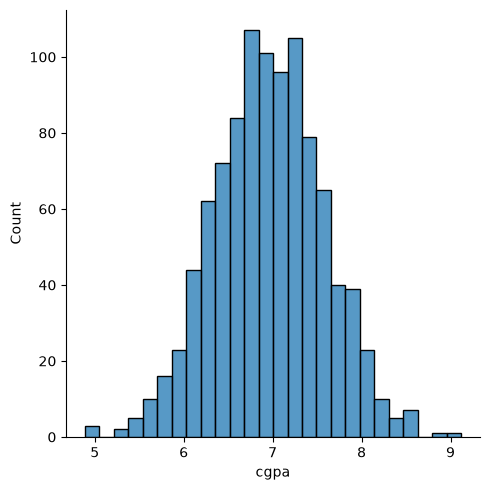

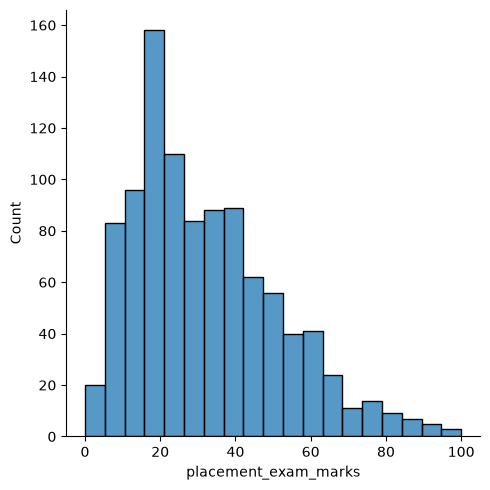

In [11]:
# Since we can see that the cgpa is distributed uniformally, we can apply z-score method on it.
# We can't do the same for the placement exam marks

sns.displot(df['cgpa'])
sns.displot(df['placement_exam_marks'])

In [12]:
print("mean value of cgpa", df['cgpa'].mean())
print("std value of cgpa", df['cgpa'].std())
print("min value of cgpa", df['cgpa'].min())
print("max value of cgpa", df['cgpa'].max())

mean value of cgpa 6.96124
std value of cgpa 0.6158978751323896
min value of cgpa 4.89
max value of cgpa 9.12


In [15]:
# Apply the formula for outliers to figure out cut out zone

print("lowest allowed", df['cgpa'].mean() - 3*df['cgpa'].std())
print("highest allowed", df['cgpa'].mean() + 3*df['cgpa'].std())

lowest allowed 5.113546374602832
highest allowed 8.808933625397168


In [16]:
# Finding the outliers

df[(df['cgpa'] > 8.808933625397168) | (df['cgpa'] < 5.113546374602832)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


# Trimming

In [ ]:
new_df = df[(df['cgpa'] < 8.808933625397168) & (df['cgpa'] > 5.113546374602832)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


# Capping

In [22]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [23]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [24]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64